In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/wangapa106g/kenya-geo/kenya-counties-subcounties-master/coordinates.ts
/kaggle/input/datasets/wangapa106g/kenya-geo/kenya-counties-subcounties-master/LICENSE
/kaggle/input/datasets/wangapa106g/kenya-geo/kenya-counties-subcounties-master/counties.ts
/kaggle/input/datasets/wangapa106g/kenya-geo/kenya-counties-subcounties-master/README.md
/kaggle/input/datasets/wangapa106g/kenya-geo/kenya-counties-subcounties-master/osm-ids.ts
/kaggle/input/datasets/wangapa106g/kenya-geo/kenya-counties-subcounties-master/osm-ids.json
/kaggle/input/datasets/wangapa106g/kenya-geo/kenya-counties-subcounties-master/counties.json
/kaggle/input/datasets/wangapa106g/kenya-geo/kenya-counties-subcounties-master/generate-geometries.py
/kaggle/input/datasets/wangapa106g/kenya-geo/kenya-counties-subcounties-master/geojson/embu.json
/kaggle/input/datasets/wangapa106g/kenya-geo/kenya-counties-subcounties-master/geojson/meru.json
/kaggle/input/datasets/wangapa106g/kenya-geo/kenya-counties-subcount

In [2]:
import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt

In [3]:
donors  = pd.read_csv("/kaggle/input/datasets/wangapa106g/kenya-elections/donors.csv")
donation = pd.read_csv("/kaggle/input/datasets/wangapa106g/kenya-elections/danations.csv")
candidates  = pd.read_csv("/kaggle/input/datasets/wangapa106g/kenya-elections/candidates.csv")
election_timeline = pd.read_csv("/kaggle/input/datasets/wangapa106g/kenya-elections/election_timeline.csv")
public_projects = pd.read_csv("/kaggle/input/datasets/wangapa106g/kenya-elections/public_projects.csv")

In [4]:
import os
import json

# Paths to your folders
COUNTY_PATH = '/kaggle/input/datasets/wangapa106g/kenya-geo/kenya-counties-subcounties-master/counties'
COORD_PATH = '/kaggle/input/datasets/wangapa106g/kenya-geo/kenya-counties-subcounties-master/coordinates'
OUTPUT_FILE = 'kenya_master_map.geojson'

def generate_master_geojson():
    master_geojson = {
        "type": "FeatureCollection",
        "features": []
    }

    # Iterate through the county metadata files
    for filename in os.listdir(COUNTY_PATH):
        if filename.endswith('.json'):
            # Load metadata
            with open(os.path.join(COUNTY_PATH, filename), 'r') as f:
                meta = json.load(f)
            
            # Load corresponding coordinates
            coord_file = os.path.join(COORD_PATH, filename)
            if os.path.exists(coord_file):
                with open(coord_file, 'r') as f:
                    coords = json.load(f)
                
                # Create a GeoJSON Feature
                feature = {
                    "type": "Feature",
                    "id": meta.get("osm_id"),
                    "properties": {
                        "name": meta.get("localname"),
                        "code": meta.get("extratags", {}).get("COUNTY_COD"),
                        "iso": meta.get("names", {}).get("ISO3166-2"),
                        "capital_constituency": meta.get("extratags", {}).get("CONSTITUEN"),
                        "area_sq_units": meta.get("extratags", {}).get("Shape_Area"),
                        "center": coords.get("center")
                    },
                    "geometry": coords.get("geometries")
                }
                master_geojson["features"].append(feature)

    # Save the result
    with open(OUTPUT_FILE, 'w') as f:
        json.dump(master_geojson, f)
    
    print(f"Successfully created {OUTPUT_FILE} with {len(master_geojson['features'])} counties.")

generate_master_geojson()

Successfully created kenya_master_map.geojson with 47 counties.


In [5]:
kenya = gpd.read_file("kenya_master_map.geojson")
kenya.head()

,name,code,iso,capital_constituency,area_sq_units,center,geometry
0,Embu,14,KE-06,RUNYENJES,0.22934267389,"[37.6652884382665, -0.5359479]","MULTIPOLYGON (((37.26792 -0.78741, 37.27314 -0..."
1,Meru County,12,KE-26,NORTH IMENTI,None,"[37.77726237163694, 0.2254509]","MULTIPOLYGON (((37.11994 -0.01985, 37.1269 -0...."
2,Elgeyo-Marakwet County,None,KE-05,None,None,"[35.561808313539316, 0.7422191499999999]","MULTIPOLYGON (((35.15229 1.19823, 35.1551 1.19..."
3,Migori County,None,KE-27,None,None,"[34.30964322421073, -1.0211616000000001]","MULTIPOLYGON (((33.93142 -0.80745, 34.08033 -0..."
4,Kajiado County,None,KE-10,None,None,"[36.78625503675998, -2.12171705]","MULTIPOLYGON (((36.00092 -2.10548, 36.00074 -2..."


In [6]:
kenya.shape

(47, 7)

In [7]:
donations_full = donation.merge(candidates, on="candidate_id") \
                          .merge(donors, on="donor_id")

donations_full.head()

,donation_id,candidate_id,donor_id,amount,date,name,party,county_x,position,donor_name,donor_type,county_y
0,1001,1,101,5000000,2026-05-10,James Mwangi,Reform Party,Nairobi,Governor,BlueWave Contractors Ltd,Company,Nairobi
1,1002,1,103,200000,2026-05-12,James Mwangi,Reform Party,Nairobi,Governor,John Kamau,Individual,Nairobi
2,1003,2,104,3000000,2026-06-01,Faith Achieng,Unity Party,Kisumu,Governor,Victoria Traders Ltd,Company,Kisumu
3,1004,2,105,150000,2026-06-03,Faith Achieng,Unity Party,Kisumu,Governor,Peter Otieno,Individual,Kisumu
4,1005,3,106,4500000,2026-06-15,David Kiptoo,National Alliance,Uasin Gishu,Senator,Rift Infrastructure Ltd,Company,Uasin Gishu


In [8]:
# Total per donor per candidate
donor_totals = donations_full.groupby(
    ["candidate_id", "donor_id"]
)["amount"].sum().reset_index()

# Total per candidate
candidate_totals = donations_full.groupby(
    "candidate_id"
)["amount"].sum().reset_index()

merged = donor_totals.merge(
    candidate_totals,
    on="candidate_id",
    suffixes=("_donor", "_total")
)

merged["donor_share"] = merged["amount_donor"] / merged["amount_total"]

# HHI per candidate
hhi = merged.groupby("candidate_id")["donor_share"] \
            .apply(lambda x: np.sum(x**2)) \
            .reset_index(name="hhi")

display(hhi.head())

,candidate_id,hhi
0,1,0.952409
1,2,0.909297
2,3,1.000000
3,4,1.000000
4,5,1.000000


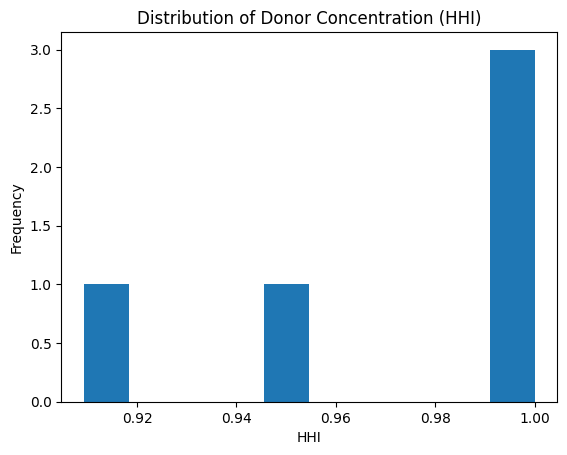

In [9]:
import matplotlib.pyplot as plt

plt.figure()
plt.hist(hhi["hhi"], bins=10)
plt.title("Distribution of Donor Concentration (HHI)")
plt.xlabel("HHI")
plt.ylabel("Frequency")
plt.show()

In [10]:
overlap = donations_full.merge(
    public_projects,
    left_on="donor_name",
    right_on="contractor"
)

overlap[[
    "candidate_id",
    "donor_name",
    "county_x",
    "project_value"
]]

,candidate_id,donor_name,county_x,project_value
0,1,BlueWave Contractors Ltd,Nairobi,15000000
1,2,Victoria Traders Ltd,Kisumu,12000000
2,3,Rift Infrastructure Ltd,Uasin Gishu,18000000
3,4,Sunrise Holdings Ltd,Nakuru,14000000
4,5,Coastal Supplies Ltd,Mombasa,10000000
5,1,BlueWave Contractors Ltd,Nairobi,15000000


In [11]:
overlap_flag = overlap.groupby("candidate_id") \
                       .size() \
                       .reset_index(name="contractor_links")

overlap_flag["contractor_risk"] = 1

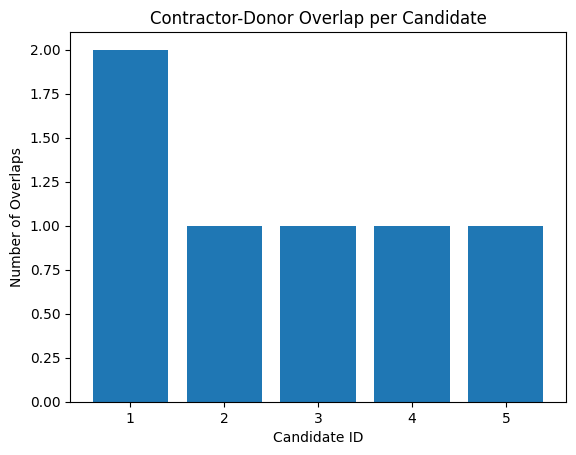

In [12]:
plt.figure()
plt.bar(overlap_flag["candidate_id"], overlap_flag["contractor_links"])
plt.title("Contractor-Donor Overlap per Candidate")
plt.xlabel("Candidate ID")
plt.ylabel("Number of Overlaps")
plt.show()

In [13]:
# Example: 60 days before election
import pandas as pd
import numpy as np

donations_full["date"] = pd.to_datetime(donations_full["date"])
election_date = pd.to_datetime("2027-08-09")

donations_full["days_to_election"] = (
    election_date - donations_full["date"]
).dt.days

surge = donations_full[
    donations_full["days_to_election"] <= 60
]

surge_flag = surge.groupby("candidate_id") \
                   .size() \
                   .reset_index(name="late_donations")

surge_flag["surge_risk"] = 1

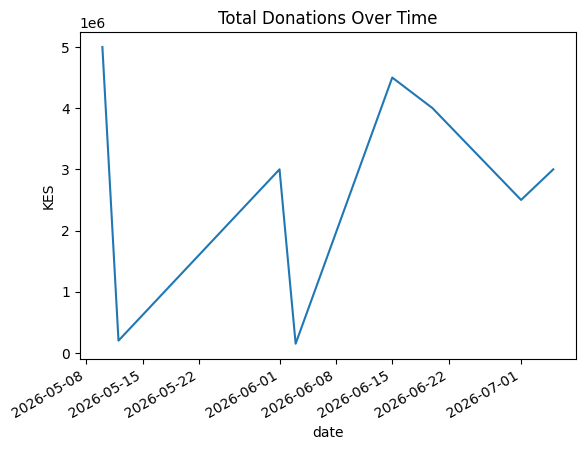

In [14]:
plt.figure()
donations_full.groupby("date")["amount"].sum().plot()
plt.title("Total Donations Over Time")
plt.ylabel("KES")
plt.show()

In [15]:
risk = hhi.merge(overlap_flag[["candidate_id","contractor_risk"]],
                 on="candidate_id", how="left")

risk = risk.merge(surge_flag[["candidate_id","surge_risk"]],
                  on="candidate_id", how="left")

risk = risk.fillna(0)

# Weighted score
risk["pfrs"] = (
    0.5 * risk["hhi"] +
    0.3 * risk["contractor_risk"] +
    0.2 * risk["surge_risk"]
)

risk.head()

,candidate_id,hhi,contractor_risk,surge_risk,pfrs
0,1,0.952409,1,0.0,0.776205
1,2,0.909297,1,0.0,0.754649
2,3,1.000000,1,0.0,0.800000
3,4,1.000000,1,0.0,0.800000
4,5,1.000000,1,0.0,0.800000


In [16]:
candidate_county = donations_full[["candidate_id","county_x"]] \
                    .drop_duplicates()

risk = risk.merge(candidate_county, on="candidate_id")

county_risk = risk.groupby("county_x")["pfrs"] \
                   .mean() \
                   .reset_index()

county_risk.head()

,county_x,pfrs
0,Kisumu,0.754649
1,Mombasa,0.800000
2,Nairobi,0.776205
3,Nakuru,0.800000
4,Uasin Gishu,0.800000


In [17]:
import geopandas as gpd
import folium

counties_gdf = kenya.copy()

map_data = counties_gdf.merge(
    county_risk,
    left_on="name",
    right_on="county_x"
)

In [18]:
map_data.columns

Index(['name', 'code', 'iso', 'capital_constituency', 'area_sq_units',
       'center', 'geometry', 'county_x', 'pfrs'],
      dtype='object')

In [19]:
map_data_clean = map_data[[
    "name",
    "pfrs",
    "geometry"
]].copy()

# Replace missing scores with 0
map_data_clean["pfrs"] = map_data_clean["pfrs"].fillna(0)

# Ensure correct CRS for Folium
map_data_clean = map_data_clean.to_crs(epsg=4326)

In [20]:
geojson_data = map_data_clean.to_json()

In [21]:
import folium

m = folium.Map(location=[0.5, 37.5], zoom_start=6)

# Choropleth layer
folium.Choropleth(
    geo_data=geojson_data,
    data=map_data_clean,
    columns=["name", "pfrs"],
    key_on="feature.properties.name",
    fill_color="Reds",
    fill_opacity=0.7,
    line_opacity=0.2,
    legend_name="Political Finance Risk Score"
).add_to(m)

# Tooltip layer
folium.GeoJson(
    geojson_data,
    tooltip=folium.GeoJsonTooltip(
        fields=["name", "pfrs"],
        aliases=["County", "Risk Score"],
        localize=True
    )
).add_to(m)

folium.LayerControl().add_to(m)

m

In [22]:
# Attach candidate name + party
risk = risk.merge(
    candidates[["candidate_id", "name", "party"]],
    on="candidate_id",
    how="left"
)

# Get highest risk candidate per county
top_candidate = risk.sort_values("pfrs", ascending=False) \
                    .groupby("county_x") \
                    .first() \
                    .reset_index()

top_candidate.head()

,county_x,candidate_id,hhi,contractor_risk,surge_risk,pfrs,name,party
0,Kisumu,2,0.909297,1,0.0,0.754649,Faith Achieng,Unity Party
1,Mombasa,5,1.000000,1,0.0,0.800000,Ali Hassan,Unity Party
2,Nairobi,1,0.952409,1,0.0,0.776205,James Mwangi,Reform Party
3,Nakuru,4,1.000000,1,0.0,0.800000,Mary Wanjiru,Reform Party
4,Uasin Gishu,3,1.000000,1,0.0,0.800000,David Kiptoo,National Alliance


In [23]:
# Clean county names
map_data["county_clean"] = map_data["name"].str.replace(" County", "", regex=False).str.strip()
top_candidate["county_clean"] = top_candidate["county_x"].str.strip()

# Merge
map_enriched = map_data.merge(
    top_candidate,
    on="county_clean",
    how="left"
)

display(map_enriched.head())

,name_x,code,iso,capital_constituency,area_sq_units,center,geometry,county_x_x,pfrs_x,county_clean,county_x_y,candidate_id,hhi,contractor_risk,surge_risk,pfrs_y,name_y,party
0,Nakuru,32,KE-31,SUBUKIA,0.60725078911,"[36.10080381595827, -0.4598213]","MULTIPOLYGON (((35.47414 -0.40156, 35.4723 -0....",Nakuru,0.8,Nakuru,Nakuru,4,1.0,1,0.0,0.8,Mary Wanjiru,Reform Party


In [24]:
map_enriched.columns

Index(['name_x', 'code', 'iso', 'capital_constituency', 'area_sq_units',
       'center', 'geometry', 'county_x_x', 'pfrs_x', 'county_clean',
       'county_x_y', 'candidate_id', 'hhi', 'contractor_risk', 'surge_risk',
       'pfrs_y', 'name_y', 'party'],
      dtype='object')

In [25]:
# Clean county names
map_data["county_clean"] = (
    map_data["name"]
    .str.replace(" County", "", regex=False)
    .str.strip()
)

top_candidate["county_clean"] = (
    top_candidate["county_x"]
    .str.strip()
)

# Merge
map_enriched = map_data.merge(
    top_candidate,
    on="county_clean",
    how="left",
    suffixes=("_county", "_candidate")
)

# --- FIX COLUMN CONFUSION IMMEDIATELY ---

map_enriched = map_enriched.rename(columns={
    "name_county": "county_name",
    "name_candidate": "candidate_name",
    "pfrs_candidate": "candidate_pfrs"
})

# Drop duplicate/irrelevant columns safely
map_enriched = map_enriched.drop(columns=[
    "pfrs_county",
    "county_x_county",
    "county_x_candidate",
    "center",
    "code",
    "iso",
    "capital_constituency",
    "area_sq_units"
], errors="ignore")

display(map_enriched.head())

,county_name,geometry,county_clean,candidate_id,hhi,contractor_risk,surge_risk,candidate_pfrs,candidate_name,party
0,Nakuru,"MULTIPOLYGON (((35.47414 -0.40156, 35.4723 -0....",Nakuru,4,1.0,1,0.0,0.8,Mary Wanjiru,Reform Party


In [26]:
# --- Clean county names ---
map_data["county_clean"] = (
    map_data["name"]
    .str.replace(" County", "", regex=False)
    .str.strip()
)

top_candidate["county_clean"] = (
    top_candidate["county_x"]
    .str.strip()
)

# --- Controlled merge with suffixes ---
map_enriched = map_data.merge(
    top_candidate,
    on="county_clean",
    how="left",
    suffixes=("_county", "_candidate")
)

# --- Rename clearly ---
map_enriched = map_enriched.rename(columns={
    "name_county": "county_name",
    "name_candidate": "candidate_name",
    "pfrs_candidate": "candidate_pfrs"
})

# --- Fill missing risk scores ---
map_enriched["candidate_pfrs"] = map_enriched["candidate_pfrs"].fillna(0)

# --- Drop noisy / conflicting columns ---
map_enriched = map_enriched.drop(columns=[
    "pfrs_county",
    "county_x_county",
    "county_x_candidate",
    "center",
    "code",
    "iso",
    "capital_constituency",
    "area_sq_units"
], errors="ignore")

# --- Keep only required fields ---
map_enriched = map_enriched[[
    "county_name",
    "candidate_name",
    "party",
    "candidate_pfrs",
    "hhi",
    "contractor_risk",
    "surge_risk",
    "geometry"
]]

# Ensure correct CRS for folium
map_enriched = map_enriched.to_crs(epsg=4326)

display(map_enriched.head())

,county_name,candidate_name,party,candidate_pfrs,hhi,contractor_risk,surge_risk,geometry
0,Nakuru,Mary Wanjiru,Reform Party,0.8,1.0,1,0.0,"MULTIPOLYGON (((35.47414 -0.40156, 35.4723 -0...."


In [27]:
def risk_explanation(row):
    reasons = []

    if pd.notna(row["hhi"]) and row["hhi"] > 0.6:
        reasons.append("High donor concentration")

    if pd.notna(row["contractor_risk"]) and row["contractor_risk"] == 1:
        reasons.append("Donor linked to public contract")

    if pd.notna(row["surge_risk"]) and row["surge_risk"] == 1:
        reasons.append("Late donation surge detected")

    if len(reasons) == 0:
        return "No major risk indicators detected"

    return ", ".join(reasons)

In [28]:
import folium

def risk_color(score):
    if score > 0.7:
        return "darkred"
    elif score > 0.4:
        return "orange"
    else:
        return "green"

m = folium.Map(location=[0.5, 37.5], zoom_start=6)

for _, row in map_enriched.iterrows():

    explanation = risk_explanation(row)

    popup_html = f"""
    <b>County:</b> {row['county_name']}<br>
    <b>Top Risk Candidate:</b> {row['candidate_name']}<br>
    <b>Party:</b> {row['party']}<br>
    <b>Risk Score:</b> {round(row['candidate_pfrs'],2)}<br>
    <b>Why flagged:</b> {explanation}
    """

    folium.GeoJson(
        row["geometry"],
        style_function=lambda feature, score=row["candidate_pfrs"]: {
            "fillColor": risk_color(score),
            "color": "black",
            "weight": 1,
            "fillOpacity": 0.6
        },
        tooltip=popup_html
    ).add_to(m)

folium.LayerControl().add_to(m)

m